<a href="https://colab.research.google.com/github/WithoutAnyTime/DataExploration/blob/main/Zadanie_integracja_danych.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Zadanie

Dysponujesz danymi z portalu Our World in Data dotyczącymi:
- Pierwotnej konsumpcji energii
- Emisji CO2 z poszczególnych lat dla różnych krajów

## Część 1: Plik CSV
Utwórz plik CSV zawierający połączone dane dla Polski:
- konsumpcja energii pierwotnej
- emisja CO2
- dane z poszczególnych lat

## Część 2: Plik Excel
Stwórz plik Excel z osobnymi zakładkami dla każdego kraju:
- UE
- USA
- Chiny
- Indie

Każda zakładka powinna zawierać dane o konsumpcji energii i emisji CO2.

## Część 3: Baza danych SQLite
Utwórz bazę danych SQLite z tabelą zawierającą:
- kraj
- rok
- emisja CO2
- konsumpcja energii

Dane powinny obejmować: Polskę, Niemcy i Hiszpanię.

## Część 4: Analiza i wizualizacja
Na podstawie danych z pliku Excel i bazy SQLite utwórz wykresy:
- emisja CO2 w zależności od roku (dla wybranego kraju)
- konsumpcja energii pierwotnej w zależności od roku (dla wybranego kraju)
- **dla chęnych szukanie koreacji**

In [16]:
df_co2 = pd.read_csv("co2-emissions-per-capita.csv")
df_co2.head()

,Entity,Year,Annual CO₂ emissions (per capita)
0,Afghanistan,1949,0.001992
1,Afghanistan,1950,0.010837
2,Afghanistan,1951,0.011625
3,Afghanistan,1952,0.011468
4,Afghanistan,1953,0.013123


In [17]:
df_primary_energy = pd.read_csv("/content/primary-energy-cons.csv")
df_primary_energy.head()

,Entity,Code,Year,Primary energy consumption (TWh)
0,Afghanistan,AFG,1980,6.337187
1,Afghanistan,AFG,1981,7.289555
2,Afghanistan,AFG,1982,7.889244
3,Afghanistan,AFG,1983,9.882159
4,Afghanistan,AFG,1984,9.929878


In [18]:
df_co2 = pd.read_csv("co2-emissions-per-capita.csv")
df_primary_energy = pd.read_csv("/content/primary-energy-cons.csv")

print("df_co2 head:")
print(df_co2.head())
print("\ndf_primary_energy head:")
print(df_primary_energy.head())

df_co2 head:
        Entity  Year  Annual CO₂ emissions (per capita)
0  Afghanistan  1949                           0.001992
1  Afghanistan  1950                           0.010837
2  Afghanistan  1951                           0.011625
3  Afghanistan  1952                           0.011468
4  Afghanistan  1953                           0.013123

df_primary_energy head:
        Entity Code  Year  Primary energy consumption (TWh)
0  Afghanistan  AFG  1980                          6.337187
1  Afghanistan  AFG  1981                          7.289555
2  Afghanistan  AFG  1982                          7.889244
3  Afghanistan  AFG  1983                          9.882159
4  Afghanistan  AFG  1984                          9.929878


In [19]:
poland_co2_df = df_co2[df_co2['Entity'] == 'Poland'].rename(columns={'Annual CO₂ emissions (per capita)': 'CO2 emissions (per capita)'})
poland_energy_df = df_primary_energy[df_primary_energy['Entity'] == 'Poland'].rename(columns={'Primary energy consumption (TWh)': 'Primary energy consumption (TWh)'}).drop(columns=['Code'])

poland_combined_df = pd.merge(poland_co2_df, poland_energy_df, on=['Year', 'Entity'], how='inner')

poland_combined_df.to_csv('poland_energy_emissions.csv', index=False)

print("Combined data for Poland saved to 'poland_energy_emissions.csv'")
print(poland_combined_df.head())

Combined data for Poland saved to 'poland_energy_emissions.csv'
   Entity  Year  CO2 emissions (per capita)  Primary energy consumption (TWh)
0  Poland  1965                    7.893703                         776.05330
1  Poland  1966                    7.996349                         791.17820
2  Poland  1967                    8.138128                         814.29987
3  Poland  1968                    8.597721                         876.36676
4  Poland  1969                    9.076116                         936.06604


In [20]:
target_entities = ['European Union', 'United States', 'China', 'India']

with pd.ExcelWriter('country_energy_emissions.xlsx') as writer:
    for entity in target_entities:
        entity_co2_df = df_co2[df_co2['Entity'] == entity].rename(columns={'Annual CO₂ emissions (per capita)': 'CO2 emissions (per capita)'})

        entity_energy_df = df_primary_energy[df_primary_energy['Entity'] == entity].rename(columns={'Primary energy consumption (TWh)': 'Primary energy consumption (TWh)'}).drop(columns=['Code'])

        combined_df = pd.merge(entity_co2_df, entity_energy_df, on=['Year', 'Entity'], how='inner')

        combined_df.to_excel(writer, sheet_name=entity, index=False)

print("Excel file 'country_energy_emissions.xlsx' created with data for European Union, United States, China, and India.")

Excel file 'country_energy_emissions.xlsx' created with data for European Union, United States, China, and India.


In [21]:
target_countries_db = ['Poland', 'Germany', 'Spain']

conn = sqlite3.connect('country_energy_emissions.db')

for country in target_countries_db:
    country_co2_df = df_co2[df_co2['Entity'] == country].rename(columns={'Annual CO₂ emissions (per capita)': 'CO2 emissions (per capita)'})

    country_energy_df = df_primary_energy[df_primary_energy['Entity'] == country].rename(columns={'Primary energy consumption (TWh)': 'Primary energy consumption (TWh)'}).drop(columns=['Code'])

    combined_db_df = pd.merge(country_co2_df, country_energy_df, on=['Year', 'Entity'], how='inner')

    combined_db_df.to_sql(country, conn, if_exists='replace', index=False)

conn.close()

print("SQLite database 'country_energy_emissions.db' created with tables for Poland, Germany, and Spain.")

SQLite database 'country_energy_emissions.db' created with tables for Poland, Germany, and Spain.


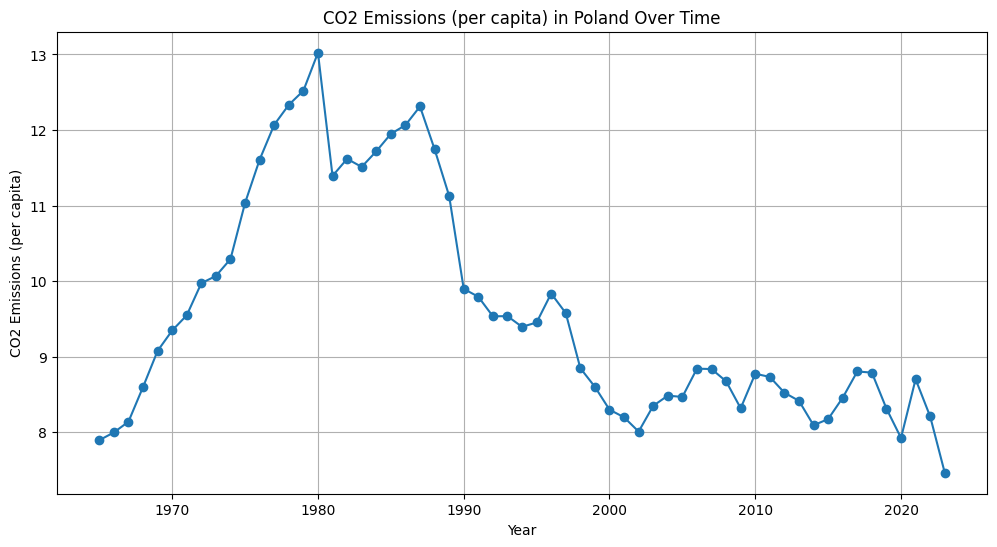

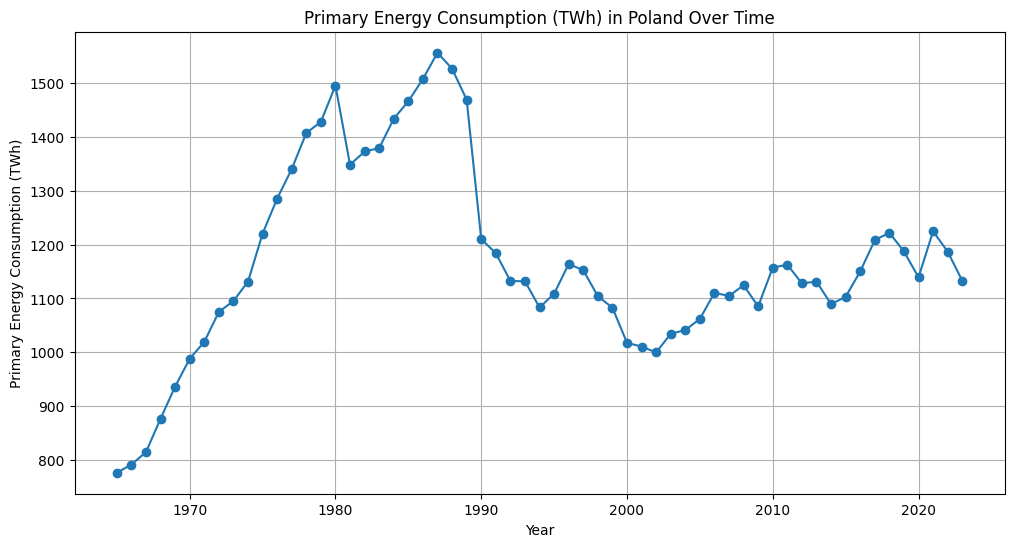

In [22]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('country_energy_emissions.db')

selected_country = 'Poland'
poland_data = pd.read_sql_query(f"SELECT * FROM '{selected_country}'", conn)

plt.figure(figsize=(12, 6))
plt.plot(poland_data['Year'], poland_data['CO2 emissions (per capita)'], marker='o', linestyle='-')
plt.title(f'CO2 Emissions (per capita) in {selected_country} Over Time')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (per capita)')
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(poland_data['Year'], poland_data['Primary energy consumption (TWh)'], marker='o', linestyle='-')
plt.title(f'Primary Energy Consumption (TWh) in {selected_country} Over Time')
plt.xlabel('Year')
plt.ylabel('Primary Energy Consumption (TWh)')
plt.grid(True)
plt.show()

conn.close()